# Regression 
## 1. Design matrix
## 2. SGD "by hand"
## 3. Pytorch
## 4. Exercises

In [1]:
import numpy as np
import numpy.random as npr
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
plt.style.use('ggplot')

Take $x$ between -1 and 1

Randomly pick $w$ and $b$ ("weight" and "bias")

$y = wx + b$

# Generate the data

In [2]:
N = 1000 # num data points
x_min = -1.0
x_max = 1.0
x_vals = np.random.uniform(x_min,x_max,N)

w = np.random.uniform(-1,1)
print("w = ", w)
b = np.random.uniform(-1,1)
print("b = ", b)

sigma = 0.5 # random noise
noise_vals = np.random.normal(0,sigma,N)

exact_vals = w * x_vals + b * np.ones(N)
obs_vals = exact_vals + noise_vals

#print(x_vals.shape)
#print(noise_vals.shape)

w =  0.7800429901395711
b =  -0.8895762574316386


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\cygwin64\tmp\ipykernel_32424\2018591260.py:1: SyntaxWarning: invalid escape sequence '\s'
  this_title = "$y = wx + b + \sigma z$"
C:\cygwin64\tmp\ipykernel_32424\2018591260.py:4: SyntaxWarning: invalid escape sequence '\s'
  this_title += ", $\sigma$ = " + str(0.001 * int(1000 * sigma))


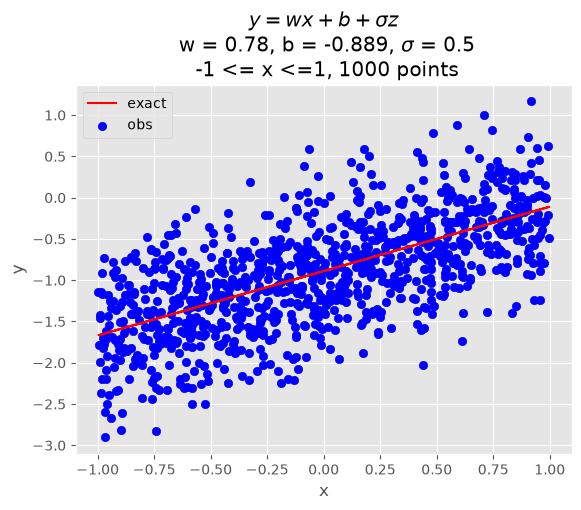

In [3]:
this_title = "$y = wx + b + \sigma z$"
this_title += "\n w = " + str(0.001 * int(1000 * w)) 
this_title += ", b = " + str(0.001 * int(1000 * b)) 
this_title += ", $\sigma$ = " + str(0.001 * int(1000 * sigma)) 
this_title += "\n -1 <= x <=1, " + str(N) + " points"

plt.plot(x_vals, exact_vals, color="red", label = "exact")
plt.scatter(x_vals, obs_vals, color = "blue", label = "obs")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(this_title)
plt.show()

## 1. Analytic solution (design matrix)

Given observations $(x_i, y_i)$, for $1 \le i \le N$,
define ${\hat{y}}_i = w x_i + b$.

We want to choose $w$, $b$ to minimise the loss
$L = {\frac{1}{N}} \sum_{i=1}^N (y_i - {\hat{y}}_i)^2$

By calculus:
\begin{equation*}
\left[
  \begin{matrix}
    S_{xx} & S_x \\ S_x & 1
  \end{matrix}
\right]
\left[
  \begin{matrix}
    w \\ b
  \end{matrix}
\right]
=
\left[
  \begin{matrix}
    S_{xy} \\ S_y
  \end{matrix}
\right]
\quad \implies \quad
\left[
  \begin{matrix}
    \hat{w} \\ \hat{b}
  \end{matrix}
\right]
=
{\frac{1}{(S_{xx} - S_x^2)}}
\left[
\begin{matrix}
    S_{xy} - S_x S_y \\ S_{xx} S_y - S_x S_{xy}
  \end{matrix}
\right]
\end{equation*}

In [4]:
S_x = np.sum(x_vals) / N
S_xx = np.sum(x_vals * x_vals) / N
S_y = np.sum(obs_vals) / N
S_xy = np.sum(x_vals * obs_vals) / N
denom = S_xx - S_x**2
w_hat = (1.0 / denom) * (S_xy - S_x * S_y)
b_hat = (1.0 / denom) * (S_xx * S_y - S_x * S_xy)
print("actual w = ", w, ", estimated w = ", w_hat)
print("actual b = ", b, ", estimated b = ", b_hat)

est_vals = w_hat * x_vals + b_hat * np.ones(N)

actual w =  0.7800429901395711 , estimated w =  0.7740528594957204
actual b =  -0.8895762574316386 , estimated b =  -0.9050752226208414


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\cygwin64\tmp\ipykernel_32424\2256005741.py:1: SyntaxWarning: invalid escape sequence '\s'
  this_title = "$y = wx + b + \sigma z$"
C:\cygwin64\tmp\ipykernel_32424\2256005741.py:5: SyntaxWarning: invalid escape sequence '\s'
  this_title += ", $\sigma$ = " + str(0.001 * int(1000 * sigma))


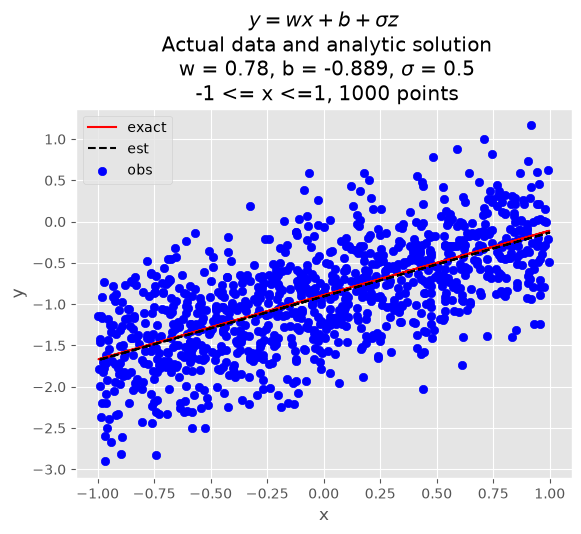

In [5]:
this_title = "$y = wx + b + \sigma z$"
this_title += "\n Actual data and analytic solution"
this_title += "\n w = " + str(0.001 * int(1000 * w)) 
this_title += ", b = " + str(0.001 * int(1000 * b)) 
this_title += ", $\sigma$ = " + str(0.001 * int(1000 * sigma)) 
this_title += "\n -1 <= x <=1, " + str(N) + " points"

plt.plot(x_vals, exact_vals, color="red", label = "exact")
plt.plot(x_vals, est_vals, color = "black", label = "est", linestyle = "dashed")
plt.scatter(x_vals, obs_vals, color = "blue", label = "obs")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(this_title)
plt.show()

# 2. SGD "by hand"
\begin{equation*}
\theta = 
\left[
\begin{matrix}
    w \\ b
  \end{matrix}
\right]
, \quad
L(\theta, x, y) = {\frac{1}{N}}\sum_{i=1}^N (y_i - (w x_i + b))^2
\end{equation*}
\begin{equation*}
\nabla_\theta L (\theta, x, y) = 
\left[
\begin{matrix}
    {\partial L}/{\partial w} \\ {\partial L}/{\partial b}
  \end{matrix}
\right]
=
\left[
\begin{matrix}
    2(w S_{xx} + b S_x - S_{xy}) \\ 2(w S_x + b - S_y)
  \end{matrix}
\right]
=
2 
\left[
\begin{matrix}
    S_{xx} & S_x \\ S_x & 1
  \end{matrix}
\right]
\theta
 - 2 
\left[
\begin{matrix}
    S_{xy} \\ S_y
  \end{matrix}
\right]
\end{equation*}
\begin{equation*}
\theta_{i+1} = \theta_i - \eta \nabla_\theta L (\theta, x, y)
\end{equation*}

## 2.1. Using all data points, and analytic form for $\nabla_\theta L$

In [6]:
num_iterations = 2000
eta = 0.01 # learning rate

A = np.array([S_xx, S_x, S_x, 1.0]).reshape(2,2)
#print(A)
B = np.array([S_xy, S_y]).reshape(2,1)
#print(B)

sgd_w_vals = np.zeros(num_iterations + 1)
sgd_b_vals = np.zeros(num_iterations + 1)

theta_zero = np.array([0.0,0.0]).reshape(2,1)
theta = theta_zero
i_vals = range(num_iterations + 1)
for i in i_vals:
    #print(i, "A = ", A, ", theta = ", theta, ", A @ theta = ", A @ theta)
    sgd_w_vals[i] = theta[0,0]
    sgd_b_vals[i] = theta[1,0]
    grad_theta = 2 * (A @ theta) - 2 * B
    theta -= eta * grad_theta

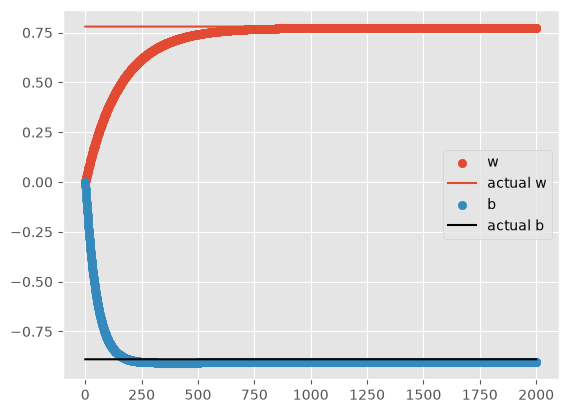

In [7]:
actual_w_vals = w * np.ones(len(sgd_w_vals))
actual_b_vals = b * np.ones(len(sgd_b_vals))

plt.scatter(i_vals, sgd_w_vals, label = "w")
plt.plot(i_vals, actual_w_vals, label = "actual w")
plt.scatter(i_vals, sgd_b_vals, label="b")
plt.plot(i_vals, actual_b_vals, label = "actual b", color = "black")
plt.legend()
plt.show()

## 2.2. Batch-sampled data points, analytic form for $\nabla_\theta L$

In [10]:
num_iterations = 1000
eta = 0.01
batch_size = 32 

sgd_w_vals = np.zeros(num_iterations + 1)
sgd_b_vals = np.zeros(num_iterations + 1)

theta_zero = np.array([0.0,0.0]).reshape(2,1)

x_indices = np.arange(len(x_vals))

theta = theta_zero
i_vals = range(num_iterations + 1)
for i in i_vals:

    random_indices = np.random.choice(x_indices, size=batch_size, replace=False)
    batch_x_vals = x_vals[random_indices]
    batch_obs_vals = obs_vals[random_indices]
    
    batch_S_x = np.sum(batch_x_vals) / batch_size
    batch_S_xx = np.sum(batch_x_vals * batch_x_vals) / batch_size
    batch_S_y = np.sum(batch_obs_vals) / batch_size
    batch_S_xy = np.sum(batch_x_vals * batch_obs_vals) / batch_size 
    
    A = np.array([batch_S_xx, batch_S_x, batch_S_x, 1.0]).reshape(2,2)
    B = np.array([batch_S_xy, batch_S_y]).reshape(2,1)
    
    #print(i, "A = ", A, ", theta = ", theta, ", A @ theta = ", A @ theta)
    sgd_w_vals[i] = theta[0,0]
    sgd_b_vals[i] = theta[1,0]
    grad_theta = 2 * (A @ theta) - 2 * B
    theta -= eta * grad_theta


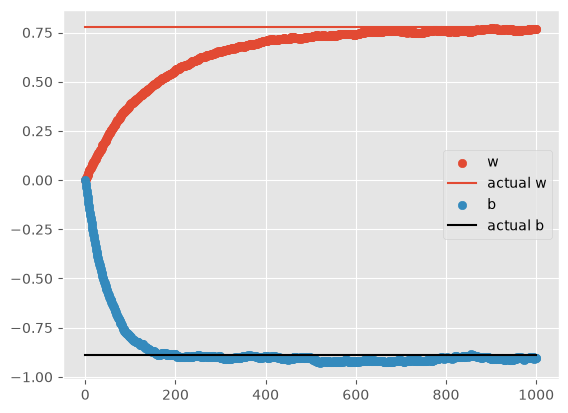

In [11]:
actual_w_vals = w * np.ones(len(sgd_w_vals))
actual_b_vals = b * np.ones(len(sgd_b_vals))

plt.scatter(i_vals, sgd_w_vals, label = "w")
plt.plot(i_vals, actual_w_vals, label = "actual w")
plt.scatter(i_vals, sgd_b_vals, label="b")
plt.plot(i_vals, actual_b_vals, label = "actual b", color="black")
plt.legend()
plt.show()

## 2.3. Batch-sampled data points, numerical estimate for $\nabla_\theta L$

In [12]:
def MeanSquaredErrorLoss(obs_y : np.ndarray, est_y : np.ndarray) -> float:
    # obs_y : observed values
    # est_y : (model) estimated values

    if obs_y.shape != est_y.shape:
        return float.NaN

    num_values = obs_y.size

    mse_loss = (1.0 / num_values) * (np.sum(obs_y - est_y))**2

    return mse_loss

In [13]:
def calculate_wx_plus_b(w : float, x_vals : np.ndarray, b : float) -> np.ndarray:
    return w * x_vals + b * np.ones(len(x_vals))

In [18]:
num_iterations = 5000
eta = 0.01
batch_size = 32
eps = 0.001

sgd_w_vals = np.zeros(num_iterations + 1)
sgd_b_vals = np.zeros(num_iterations + 1)

theta_zero = np.array([0.0,0.0]).reshape(2,1)

x_indices = np.arange(len(x_vals))

theta = theta_zero
i_vals = range(num_iterations + 1)
for i in i_vals:

    sgd_w = theta[0,0]
    sgd_b = theta[1,0]

    random_indices = np.random.choice(x_indices, size=batch_size, replace=False)
    batch_x_vals = x_vals[random_indices]
    batch_obs_vals = obs_vals[random_indices]
    
    batch_est_vals = calculate_wx_plus_b(sgd_w, batch_x_vals, sgd_b)
    batch_est_vals_w_plus_eps = calculate_wx_plus_b(sgd_w + eps, batch_x_vals, sgd_b)
    batch_est_vals_b_plus_eps = calculate_wx_plus_b(sgd_w, batch_x_vals, sgd_b + eps)

    this_loss = MeanSquaredErrorLoss(batch_obs_vals, batch_est_vals)
    this_loss_w_plus_eps = MeanSquaredErrorLoss(batch_obs_vals, batch_est_vals_w_plus_eps)
    this_loss_b_plus_eps = MeanSquaredErrorLoss(batch_obs_vals, batch_est_vals_b_plus_eps)
    
    dL_dw = (1.0 / eps) * (this_loss_w_plus_eps - this_loss)
    dL_db = (1.0 / eps) * (this_loss_b_plus_eps - this_loss)
    grad_L = np.array([dL_dw, dL_db]).reshape(2,1)

    theta -= eta * grad_L

    #print(i, theta)
    sgd_w_vals[i] = theta[0,0]
    sgd_b_vals[i] = theta[1,0]

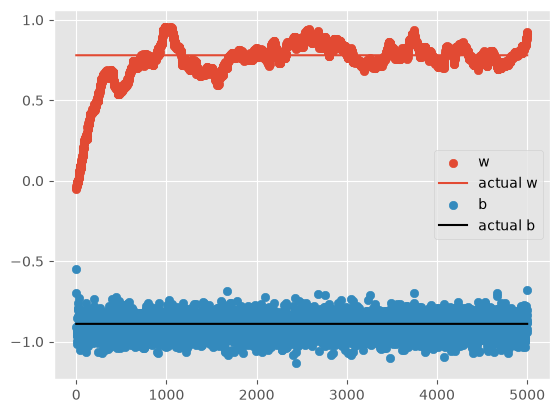

In [19]:
actual_w_vals = w * np.ones(len(sgd_w_vals))
actual_b_vals = b * np.ones(len(sgd_b_vals))

plt.scatter(i_vals, sgd_w_vals, label = "w")
plt.plot(i_vals, actual_w_vals, label = "actual w")
plt.scatter(i_vals, sgd_b_vals, label="b")
plt.plot(i_vals, actual_b_vals, label = "actual b", color="black")
plt.legend()
plt.show()

# 3. with a (very simple) neural network

In [20]:
f = model = nn.Sequential(
    nn.Linear(1, 1)
)

print(f)

weight = f[0].weight.item()
bias = f[0].bias.item()

print(f"weight: {weight}, bias: {bias}")

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)
weight: -0.5321145057678223, bias: -0.8018776178359985


In [21]:
eta = 0.1 # learning rate
optimizer = torch.optim.Adam(f.parameters(), lr=eta)
loss_fn = nn.MSELoss()

In [24]:
num_epochs = 100

X = torch.tensor(x_vals).reshape(N,1)
Y = torch.tensor(obs_vals).reshape(N,1)

train = train_model(
    f,
    X,
    Y,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=32)

Epoch 10/100, loss: 0.2585
Epoch 20/100, loss: 0.2556
Epoch 30/100, loss: 0.2558
Epoch 40/100, loss: 0.2587
Epoch 50/100, loss: 0.2561
Epoch 60/100, loss: 0.2563
Epoch 70/100, loss: 0.2605
Epoch 80/100, loss: 0.2575
Epoch 90/100, loss: 0.2545
Epoch 100/100, loss: 0.2553


In [25]:
#print(train)
weight = f[0].weight.item()
bias = f[0].bias.item()

print(f"weight: {weight}, bias: {bias}")
print(f"actual w: {w}, actual b: {b}")

weight: 0.7703246474266052, bias: -0.8848991990089417
actual w: 0.7800429901395711, actual b: -0.8895762574316386


# 4. Exercise. Repeat the above, but for a higher-dimensional example:
## $y = Wx + b$, where $x \in {\mathbb{R}}^d$, $W$ is $m \times d$, and $y, b \in {\mathbb{R}}^m$

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np


def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0,   # NEW
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    Parameters
    ----------
    model : nn.Module
    X, y : torch.Tensor or np.ndarray  -- training data
    loss_fn : callable, e.g. nn.MSELoss(), nn.BCELoss()
    optimizer : torch.optim.Optimizer
    epochs : int
    batch_size : int
    metrics : dict[str, callable] or None
        Each callable takes (y_pred, y_true) and returns a float.
    X_val, y_val : optional validation data (same format as X, y)
        validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the END of the dataset. 
        Ignored if X_val and y_val are both explicitly provided.
    verbose_every : int -- print progress every N epochs (0 to disable)
    device : torch.device or None -- defaults to CUDA if available, else CPU

    Returns
    -------
    history : dict of lists, e.g. {"loss": [...], "val_loss": [...], "accuracy": [...]}
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    X = to_tensor(X)
    y = to_tensor(y)

    # Handle validation_split (only if X_val/y_val not already given)
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        #print("running_metrics = ", running_metrics)
        n_samples = 0

        i = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            i += 1

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"

        #print("has_val = ", has_val)
        if has_val:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val)
                val_loss = loss_fn(y_val_pred, y_val).item()
                history["val_loss"].append(val_loss)
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history

In [23]:
def model_predict(model, input_data):

	is_numpy_array = isinstance(input_data, np.ndarray)
	

	# 1. Make sure input_data is a float32 tensor
	if is_numpy_array:
		input_data = torch.from_numpy(input_data).float()
	else:
		input_data = input_data.float()

	# 2. Make sure it's on the same device as the model
	device = next(model.parameters()).device
	input_data = input_data.to(device)

	# 3. Set eval mode and disable gradient tracking for inference
	model.eval()
	with torch.no_grad():
		ppred = model(input_data)
		
	# 4. return as either numpy array or as tensor, depending on input type
	if is_numpy_array:
		# return as a numpy array
		ppred_np = ppred.cpu().numpy()
		return ppred_np
	else:
		return ppred